# Use potential density and potential spicity/spiciness as features

In [1]:
import pandas as pd
import random
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm
import gsw

2026-04-14 11:37:19.650204: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Get data into dataframe
df = pd.read_csv('../../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to only have temperature, salinity and dissolved oxygen
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]']]

# Calculate density based on temperature, salinity, latitude and depth
df_ST['Pressure_[dbar]'] = gsw.p_from_z(-df_ST['Depth_[m]'].values, df_ST['Latitude_[deg_N]'].values)
df_ST['Density_[kg_per_m^3]'] = gsw.density.rho(df_ST['Absolute_Salinity_[PSU]'].values, df_ST['Conservative_Temperature_[deg_C]'].values, df_ST['Pressure_[dbar]'])
df_ST['Spice'] = gsw.spiciness0(df_ST['Absolute_Salinity_[PSU]'], df_ST['Conservative_Temperature_[deg_C]'])

# Select features for clustering
features = ['Density_[kg_per_m^3]','Spice']

In [3]:
# Define random seed for reproducibility
seed = 22
random.seed(seed)

In [4]:
# Scale data
scaler = StandardScaler()
df_ST_scaled = scaler.fit_transform(df_ST[features])

In [5]:
# set seed for reproducibility
tf.random.set_seed(seed)

# Autoencoder architecture
input_dim = df_ST_scaled.shape[1]
latent_dim = 1

# Encoder
inputs = layers.Input(shape=(input_dim,))
x = layers.Dense(16, activation='relu')(inputs)
x = layers.Dense(8, activation='relu')(x)
latent = layers.Dense(latent_dim, name="latent")(x)

# Decoder
x = layers.Dense(8, activation='relu')(latent)
x = layers.Dense(16, activation='relu')(x)
outputs = layers.Dense(input_dim)(x)

autoencoder = models.Model(inputs, outputs)
encoder = models.Model(inputs, latent)

In [6]:
early_stopping = EarlyStopping(
    monitor='val_loss',   # validation loss checked for early stopping
    patience=5,           # how many epochs to wait before stopping
    restore_best_weights=True)

autoencoder.compile(
    optimizer='adam',
    loss='mse')

autoencoder.fit(
    df_ST_scaled,
    df_ST_scaled,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    verbose=1)

Epoch 1/50
160354/160354 ━━━━━━━━━━━━━━━━━━━━ 237s 1ms/step - loss: 0.0128 - val_loss: 0.0056
Epoch 2/50
160354/160354 ━━━━━━━━━━━━━━━━━━━━ 240s 1ms/step - loss: 0.0113 - val_loss: 0.0074
Epoch 3/50
160354/160354 ━━━━━━━━━━━━━━━━━━━━ 216s 1ms/step - loss: 0.0134 - val_loss: 0.0075
Epoch 4/50
160354/160354 ━━━━━━━━━━━━━━━━━━━━ 212s 1ms/step - loss: 0.0217 - val_loss: 0.0107
Epoch 5/50
160354/160354 ━━━━━━━━━━━━━━━━━━━━ 184s 1ms/step - loss: 0.0201 - val_loss: 0.0131
Epoch 6/50
160354/160354 ━━━━━━━━━━━━━━━━━━━━ 196s 1ms/step - loss: 0.0227 - val_loss: 0.0115
Epoch 7/50
160354/160354 ━━━━━━━━━━━━━━━━━━━━ 205s 1ms/step - loss: 0.0170 - val_loss: 0.0087
Epoch 8/50
160354/160354 ━━━━━━━━━━━━━━━━━━━━ 206s 1ms/step - loss: 0.0158 - val_loss: 0.0075
Epoch 9/50
160354/160354 ━━━━━━━━━━━━━━━━━━━━ 220s 1ms/step - loss: 0.0153 - val_loss: 0.0070
Epoch 10/50
160354/160354 ━━━━━━━━━━━━━━━━━━━━ 195s 1ms/step - loss: 0.0150 - val_loss: 0.0071
Epoch 11/50
160354/160354 ━━━━━━━━━━━━━━━━━━━━ 212s 1ms/ste

In [7]:
X_latent = encoder.predict(df_ST_scaled)

356342/356342 ━━━━━━━━━━━━━━━━━━━━ 203s 568us/step


In [8]:
# Do BIC and AIC calculation for different number of clusters
bic_scores = []
n_components_range = range(1, 12)
for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=22)
    gmm.fit(X_latent)
    bic_scores.append(gmm.bic(X_latent))

Text(0.5, 1.0, 'BIC Scores for GMM with Different Number of Components')

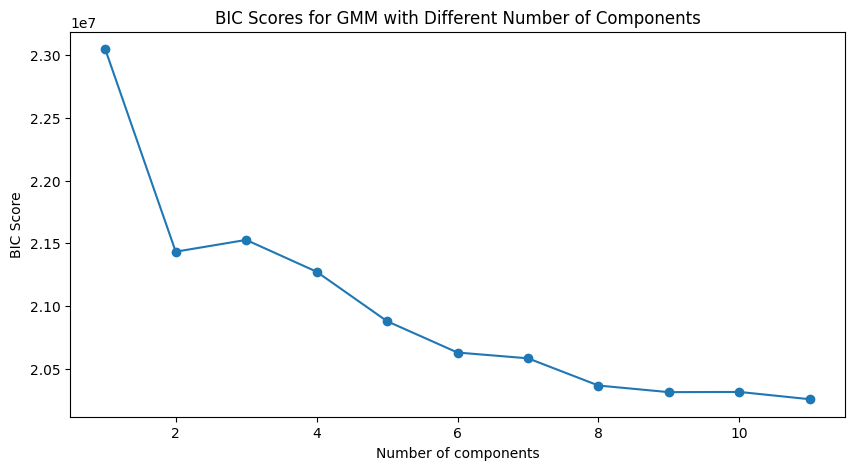

In [9]:
plt.figure(figsize=(10,5))
plt.plot(n_components_range, bic_scores, label='BIC', marker='o')
plt.xlabel('Number of components')
plt.ylabel('BIC Score')
plt.title('BIC Scores for GMM with Different Number of Components')

In [10]:
# Choice of optimal number of clusters based on BIC
optimal_n_components = 2

In [11]:
gmm = GaussianMixture(
    n_components=optimal_n_components,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seed)

labels = gmm.fit_predict(X_latent)

In [12]:
df_ST['gmm_label'] = labels

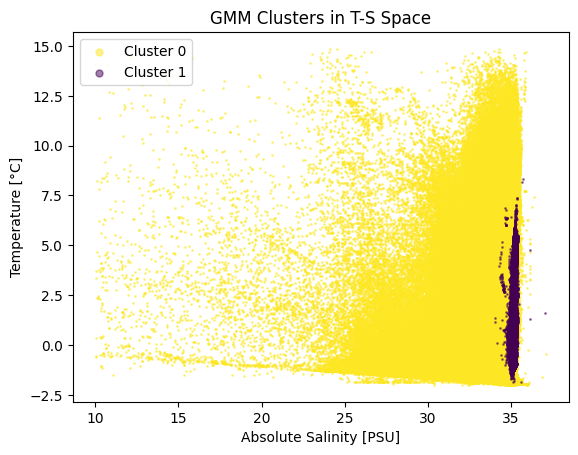

In [13]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, optimal_n_components))

for i in range(optimal_n_components):
    mask = df_ST['gmm_label'] == i
    plt.scatter(
        df_ST.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_ST.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space")
plt.legend(loc='upper left', markerscale=5)
plt.show()

In [14]:
# Sample geographically for better plotting
df_ST['gmm_label'] = labels
df_sampled = df_ST.sample(n=100000, random_state=seed)

In [15]:
# Compute data centroid (mean location)
center_lat = df_ST['Latitude_[deg_N]'].mean()
center_lon = df_ST['Longitude_[deg_E]'].mean()

colors = px.colors.sample_colorscale(
    px.colors.sequential.Plasma, # Colour scale same as continuous colour bar version but sampled to be discrete
    np.linspace(0, 1, optimal_n_components)
)

# Stepped colorscale
discrete_colorscale = []
for i, c in enumerate(colors):
    discrete_colorscale.append([i / optimal_n_components, c])
    discrete_colorscale.append([(i + 1) / optimal_n_components, c])

fig = px.scatter_geo(
    df_sampled,
    lat='Latitude_[deg_N]',
    lon='Longitude_[deg_E]',
    color='gmm_label',
    color_continuous_scale=discrete_colorscale,
    range_color=(0, optimal_n_components),
    title="GMM clusters using TS on Geographic Map"
)

fig.update_traces(
    marker=dict(size=5, opacity=0.9)
)

fig.update_coloraxes(showscale=False)  # hide colorbar

for i, c in enumerate(colors):
    fig.add_trace(
        go.Scattergeo(
            lat=[None], lon=[None],   # invisible
            mode="markers",
            marker=dict(size=8, color=c),
            name=f"Cluster {i}",
            showlegend=True
        )
    )

fig.update_geos(
    projection_type="orthographic",
    projection_rotation=dict(lat=center_lat, lon=center_lon),
    showcoastlines=True,
    showcountries=True
)

fig.update_layout(
    height=800,
    width=800,
    legend_title_text="GMM Cluster",
    legend_traceorder="normal"
)

fig.show()

In [16]:
colors = px.colors.sample_colorscale(
    px.colors.sequential.Plasma,
    np.linspace(0, 1, optimal_n_components)
)

# Stepped colorscale
discrete_colorscale = []
for i, c in enumerate(colors):
    discrete_colorscale.append([i / optimal_n_components, c])
    discrete_colorscale.append([(i + 1) / optimal_n_components, c])

fig_3d = px.scatter_3d(
    df_sampled,
    x='Latitude_[deg_N]',
    y='Longitude_[deg_E]',
    z='Depth_[m]',
    color='gmm_label',
    color_continuous_scale=discrete_colorscale,
    range_color=(0, optimal_n_components),
    title="3D Scatter Lat-Lon-Depth plot of GMM clusters"
)

fig_3d.update_traces(
    marker=dict(
        size=5
    )
)

fig_3d.update_coloraxes(showscale=False)  # hide colorbar

for i, c in enumerate(colors):
    fig_3d.add_trace(
        go.Scatter3d(
            x=[None], y=[None], z=[None],
            mode="markers",
            marker=dict(size=8, color=c),
            name=f"Cluster {i}",
            showlegend=True
        )
    )

fig_3d.update_layout(
    scene=dict(
        xaxis_title='Latitude',
        yaxis_title='Longitude',
        zaxis_title='Depth (m)',
        zaxis=dict(autorange='reversed')
    ),
    height=800,
    width=800,
    legend_title_text="GMM Cluster",
    legend_traceorder="normal"
)

fig_3d.show()


In [17]:
def cross_sec_lon(lon_value, tol=0.5):
    df_lon_slice = df_ST[
        (df_ST['Longitude_[deg_E]'] >= lon_value - tol) &
        (df_ST['Longitude_[deg_E]'] <= lon_value + tol)
    ]

    n = optimal_n_components

    # Sample full sequential colormap discretely
    base_cmap = plt.cm.viridis
    colors = base_cmap(np.linspace(0, 1, n))
    cmap = ListedColormap(colors)

    # Discrete normalization
    norm = BoundaryNorm(np.arange(-0.5, n + 0.5, 1), cmap.N)

    plt.figure(figsize=(10, 6))

    sc = plt.scatter(
        df_lon_slice['Latitude_[deg_N]'],
        df_lon_slice['Depth_[m]'],
        c=df_lon_slice['gmm_label'],
        cmap=cmap,
        norm=norm,
        s=8,
        alpha=0.6
    )

    plt.gca().invert_yaxis()
    plt.xlabel('Latitude [deg N]')
    plt.ylabel('Depth [m]')
    plt.title(f'GMM Clusters in Latitude-Depth Cross Section at Longitude ~ {lon_value}°E')

    # ---- Discrete legend (dummy handles) ----
    handles = [
        Line2D(
            [0], [0],
            marker='o',
            linestyle='',
            markersize=6,
            markerfacecolor=colors[i],
            markeredgecolor='none',
            label=f'Cluster {i}'
        )
        for i in range(n)
    ]

    plt.legend(
        handles=handles,
        title='GMM Cluster',
        loc='lower left',
    )

    plt.tight_layout()
    plt.show()

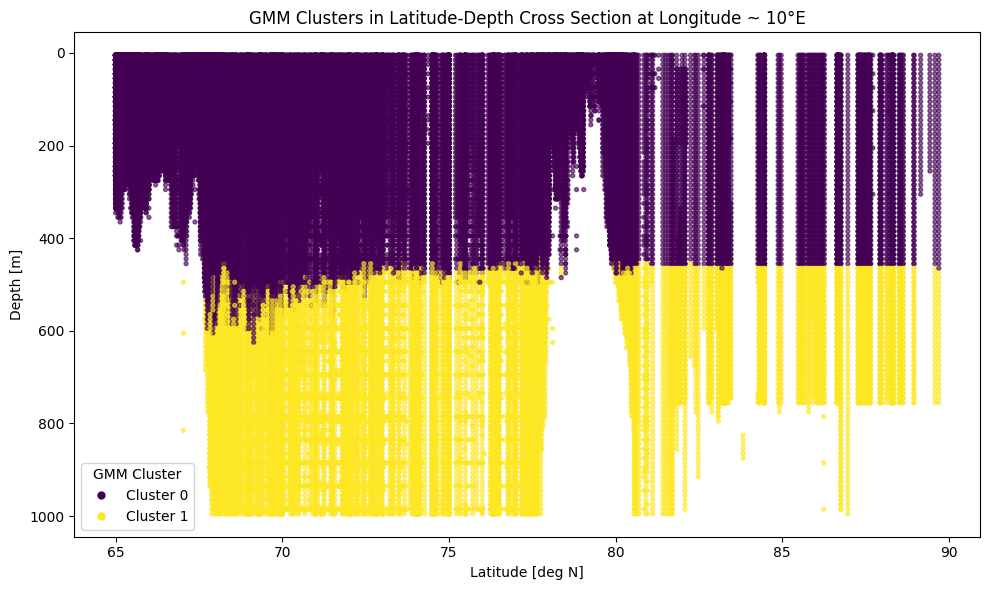

In [18]:
# Plot cross section for specific longitude slice
lon = 10
cross_sec_lon(lon, tol=0.5)

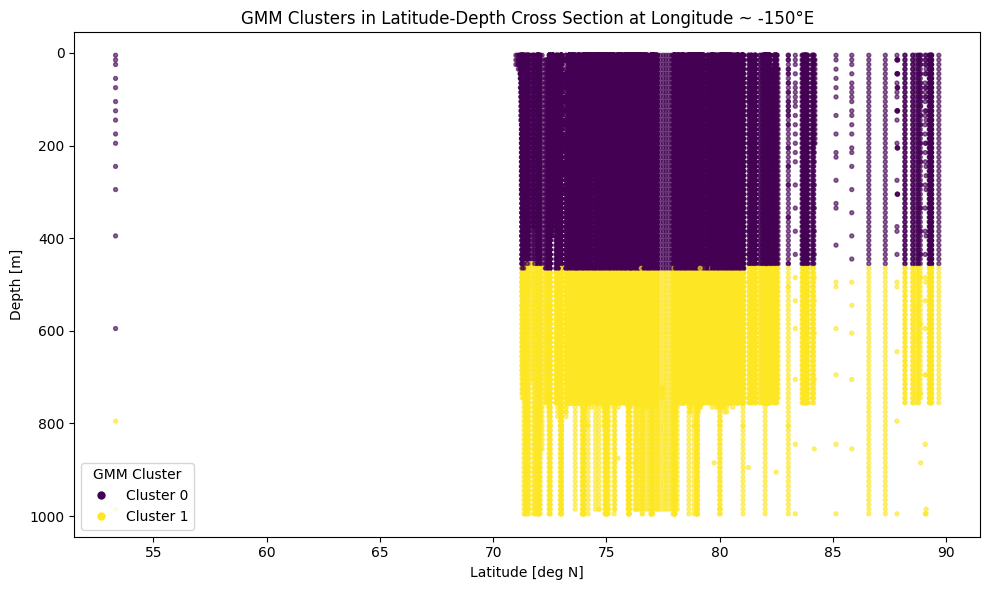

In [19]:
lon_slice = -150
cross_sec_lon(lon_slice, tol=0.5)

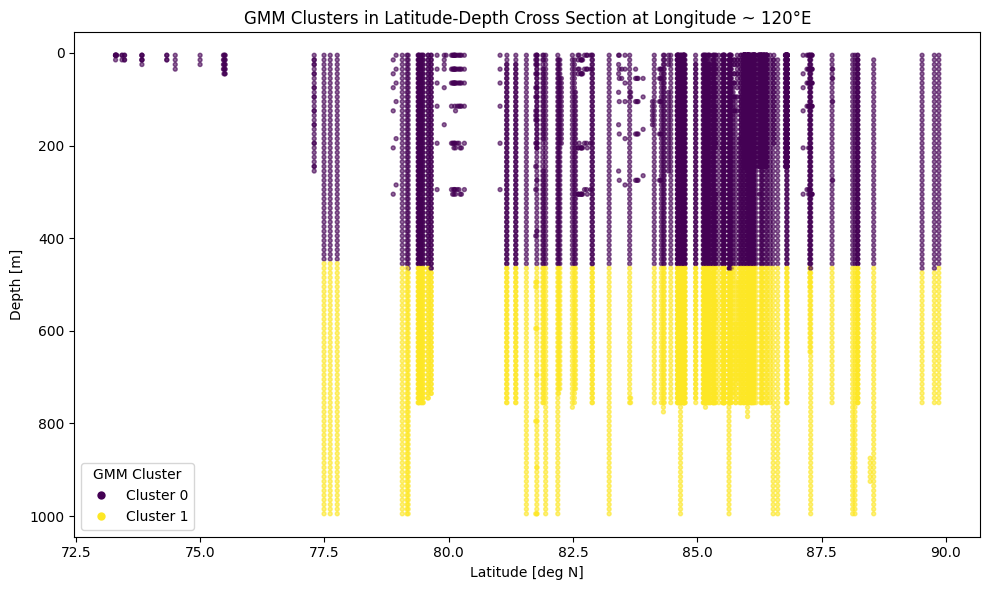

In [20]:
lon = 120
cross_sec_lon(lon, tol=0.5)

In [21]:
# Loss of information
X_recon_ae = autoencoder.predict(df_ST_scaled)
mse = np.mean((df_ST_scaled - X_recon_ae) ** 2)
print(f'Mean Squared Error of AE reconstruction: {mse}')

356342/356342 ━━━━━━━━━━━━━━━━━━━━ 225s 632us/step
Mean Squared Error of AE reconstruction: 0.010878025066243776
